## **Imports**

In [49]:
# imports
import pandas as pd
import numpy as np
import pickle as pkl
import os
import time
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import adjusted_mutual_info_score, adjusted_rand_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

## **Loading Data**

In [50]:
# read file_structure
data_path = "../../../../Merged_Data_Preprocessing/Resampled_Data_split"
with open(os.path.join(data_path, 'file_structure.pkl'), 'rb') as f:
    file_structure = pkl.load(f)

# display file structure
file_structure

{'original': {'X_path': 'Resampled_Data_split\\original\\X_original.parquet',
  'y_path': 'Resampled_Data_split\\original\\y_original.pkl'},
 'smote': {'X_path': 'Resampled_Data_split\\smote\\X_smote.parquet',
  'y_path': 'Resampled_Data_split\\smote\\y_smote.pkl'},
 'tomek': {'X_path': 'Resampled_Data_split\\tomek\\X_tomek.parquet',
  'y_path': 'Resampled_Data_split\\tomek\\y_tomek.pkl'},
 'smote_tomek': {'X_path': 'Resampled_Data_split\\smote_tomek\\X_smote_tomek.parquet',
  'y_path': 'Resampled_Data_split\\smote_tomek\\y_smote_tomek.pkl'},
 'test': {'X_path': 'Resampled_Data_split\\test\\X_test.parquet',
  'y_path': 'Resampled_Data_split\\test\\y_test.pkl'},
 'val': {'X_path': 'Resampled_Data_split\\val\\X_val.parquet',
  'y_path': 'Resampled_Data_split\\val\\y_val.pkl'}}

In [51]:
y_train = pd.read_pickle(f"{data_path}/original/y_original.pkl")
y_test = pd.read_pickle(f"{data_path}/test/y_test.pkl")
y_val = pd.read_pickle(f"{data_path}/val/y_val.pkl")

In [52]:
X_test = pd.read_parquet(f"{data_path}/test/X_test.parquet")
X_val = pd.read_parquet(f"{data_path}/val/X_val.parquet")

In [53]:
# load normalized X_train
normalized_path = "../../../../Merged_Data_Preprocessing/Normalized_Data_split"
X_train = pd.read_parquet(f"{normalized_path}/X_train_original.parquet")

In [54]:
# convert boolean columns to int
bool_cols = X_train.select_dtypes(include=['bool']).columns
if len(bool_cols) > 0:
    print(f"Converting {len(bool_cols)} boolean columns to int...")
    X_train[bool_cols] = X_train[bool_cols].astype(int)
    X_test[bool_cols] = X_test[bool_cols].astype(int)
    X_val[bool_cols] = X_val[bool_cols].astype(int)
    print("Conversion complete!")

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

Converting 7 boolean columns to int...
Conversion complete!
X_train shape: (16226, 64)
y_train shape: (16226,)


## **DBSCAN (sklearn)**

In [55]:
# train DBSCAN (sklearn)
print("Training DBSCAN (sklearn)...")
start_time = time.time()

from sklearn.decomposition import PCA
# PCA = Principal Component Analysis
pca = PCA(n_components=8, whiten=True, random_state=42)
X_train_pca = pca.fit_transform(X_train)

print("Explained variance ratio (sum):", pca.explained_variance_ratio_.sum())
    
dbscan = DBSCAN(eps=2.8, min_samples=15, n_jobs=-1)
dbscan.fit(X_train_pca)
runtime = time.time() - start_time

labels = dbscan.labels_
n_noise = np.sum(labels == -1)
noise_ratio = n_noise / len(labels)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

print(f"Runtime: {runtime:.2f}s")
print(f"Clusters: {n_clusters}")
print(f"Noise points: {n_noise} ({noise_ratio:.2%})")

Training DBSCAN (sklearn)...
Explained variance ratio (sum): 0.9999953818912435
Runtime: 5.23s
Clusters: 5
Noise points: 12 (0.07%)


In [56]:
# metrics computation
def compute_dbscan_metrics(X, labels, y_true=None):
    metrics = {}
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    metrics['n_clusters'] = n_clusters
    metrics['n_noise'] = int(np.sum(labels == -1))
    metrics['noise_ratio'] = metrics['n_noise'] / len(labels)

    mask = labels != -1
    if n_clusters > 0 and np.sum(mask) > 1:
        X_f = X.values if isinstance(X, pd.DataFrame) else X
        X_f = X_f.astype(float)
        X_non_noise = X_f[mask]
        labels_non_noise = labels[mask]
        if len(np.unique(labels_non_noise)) > 1:
            metrics['silhouette'] = silhouette_score(X_non_noise, labels_non_noise)
            metrics['davies_bouldin'] = davies_bouldin_score(X_non_noise, labels_non_noise)
            metrics['calinski_harabasz'] = calinski_harabasz_score(X_non_noise, labels_non_noise)
        else:
            metrics['silhouette'] = None
            metrics['davies_bouldin'] = None
            metrics['calinski_harabasz'] = None
    else:
        metrics['silhouette'] = None
        metrics['davies_bouldin'] = None
        metrics['calinski_harabasz'] = None

    if y_true is not None:
        y_arr = np.asarray(y_true).ravel()
        metrics['ami'] = adjusted_mutual_info_score(y_arr, labels)
        metrics['ari'] = adjusted_rand_score(y_arr, labels)
        fire_rates = {}
        for cid in set(labels):
            m = labels == cid
            if np.sum(m) > 0:
                fire_rates[cid] = float(np.mean(y_arr[m]))
        metrics['fire_rates'] = fire_rates
    return metrics

metrics = compute_dbscan_metrics(X_train, labels, y_train)

print("="*60)
print("DBSCAN METRICS")
print("="*60)
print(f"Clusters: {metrics['n_clusters']}")
print(f"Noise points: {metrics['n_noise']} ({metrics['noise_ratio']:.2%})")
print(f"Silhouette Score: {metrics['silhouette'] if metrics['silhouette'] is not None else 'N/A'}")
print(f"Davies-Bouldin Index: {metrics['davies_bouldin'] if metrics['davies_bouldin'] is not None else 'N/A'}")
print(f"Calinski-Harabasz Index: {metrics['calinski_harabasz'] if metrics['calinski_harabasz'] is not None else 'N/A'}")
print(f"AMI: {metrics.get('ami', 'N/A')}")
print(f"ARI: {metrics.get('ari', 'N/A')}")

DBSCAN METRICS
Clusters: 5
Noise points: 12 (0.07%)
Silhouette Score: -0.26858461838970066
Davies-Bouldin Index: 2.3095050912195423
Calinski-Harabasz Index: 360318.48351000587
AMI: 0.01749679787308054
ARI: 0.08719538811235165


In [57]:
# contingency table
contingency = pd.crosstab(labels, y_train, rownames=['Cluster'], colnames=['Fire'], margins=True)
contingency.index = ['Noise' if idx == -1 else f'Cluster {idx}' for idx in contingency.index[:-1]] + ['Total']
contingency.columns = ['No Fire', 'Fire', 'Total']
print("Contingency table (counts):\n", contingency)

contingency_pct = pd.crosstab(labels, y_train, rownames=['Cluster'], colnames=['Fire'], normalize='index') * 100
contingency_pct.index = ['Noise' if idx == -1 else f'Cluster {idx}' for idx in contingency_pct.index]
contingency_pct.columns = ['No Fire %', 'Fire %']
print("\nContingency table (percentages):\n", contingency_pct)

Contingency table (counts):
            No Fire  Fire  Total
Noise            7     5     12
Cluster 0    14053   749  14802
Cluster 1      856   164   1020
Cluster 2      290    16    306
Cluster 3       32     0     32
Cluster 4       47     7     54
Total        15285   941  16226

Contingency table (percentages):
             No Fire %     Fire %
Noise       58.333333  41.666667
Cluster 0   94.939873   5.060127
Cluster 1   83.921569  16.078431
Cluster 2   94.771242   5.228758
Cluster 3  100.000000   0.000000
Cluster 4   87.037037  12.962963


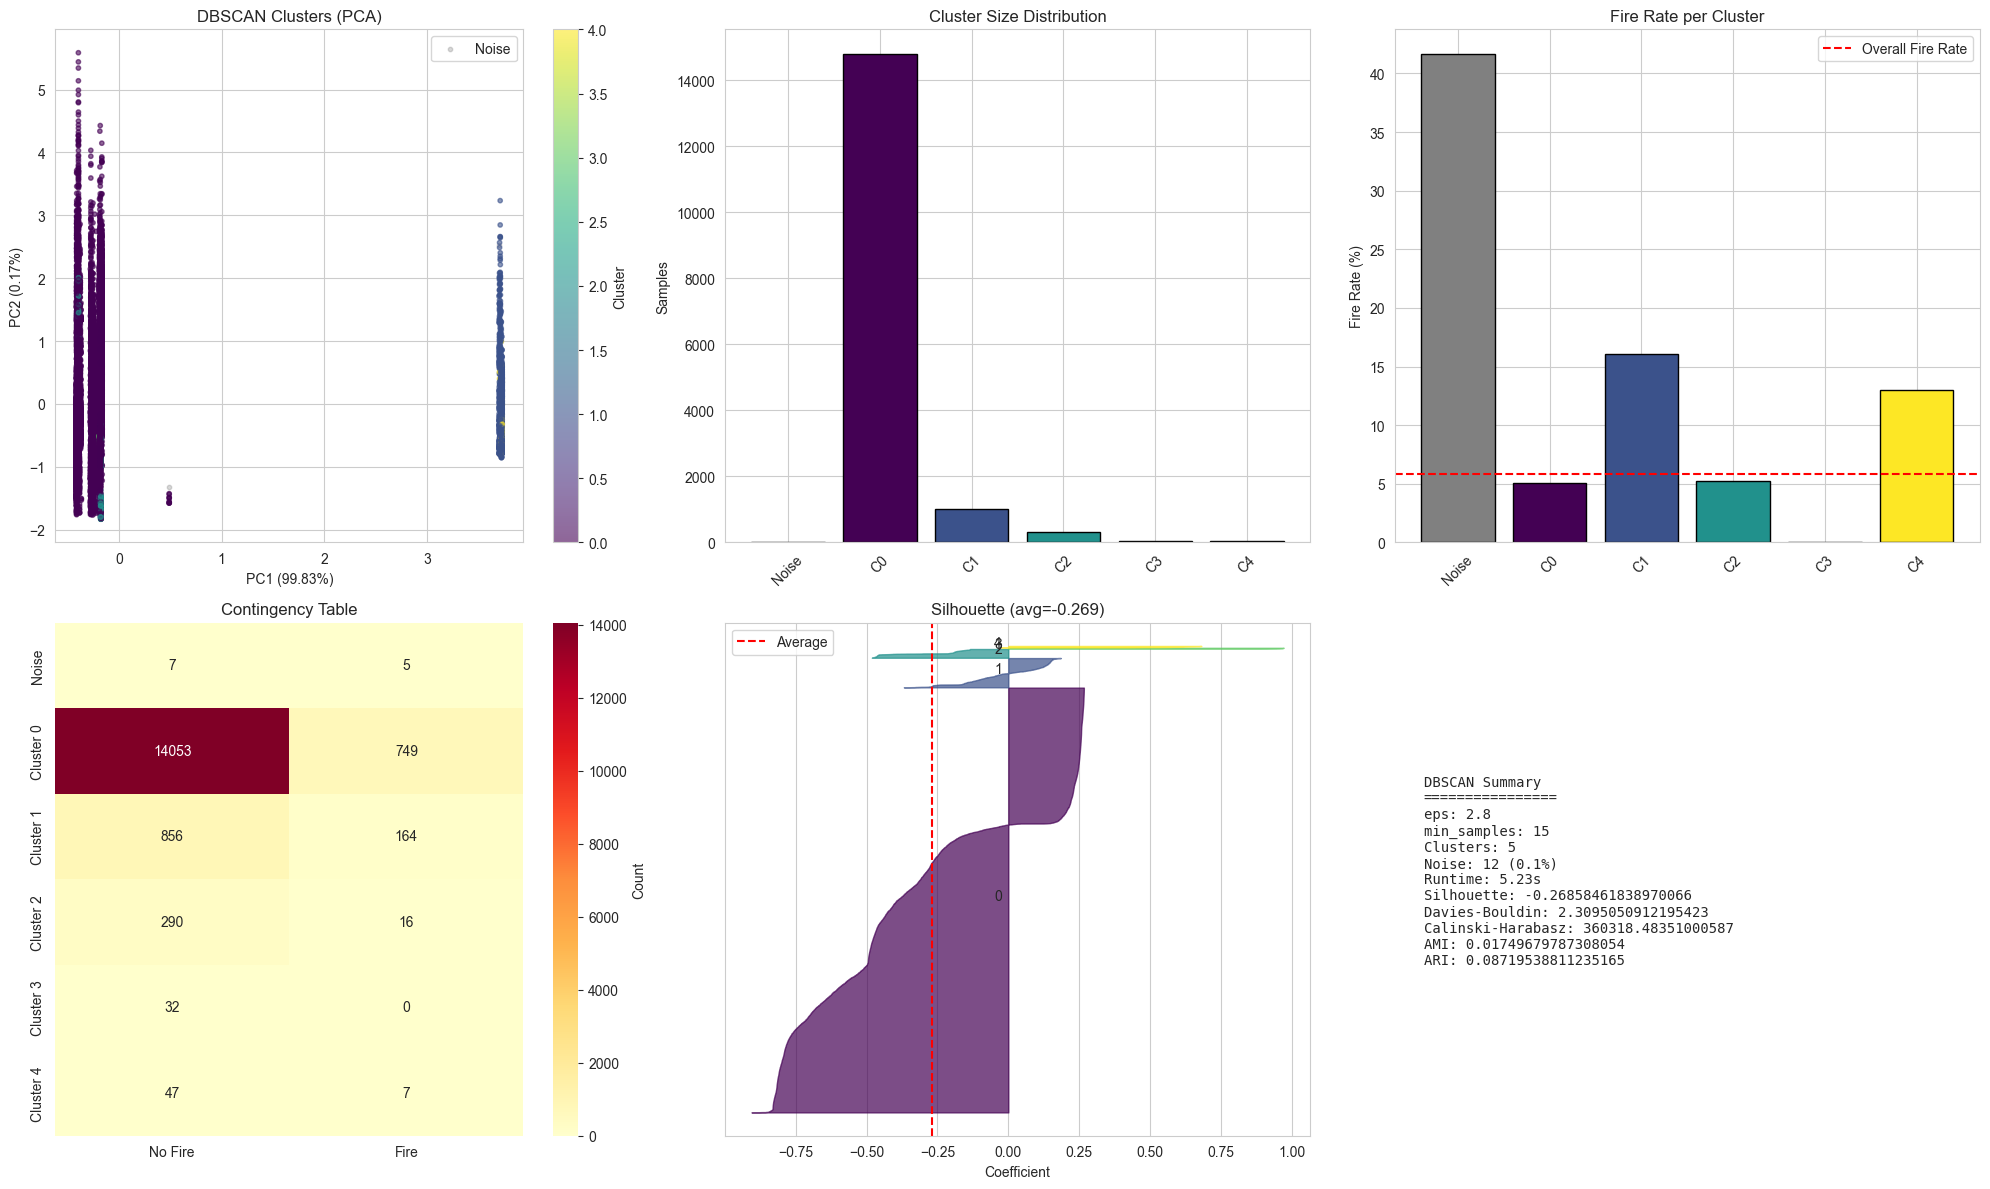

Visualization complete!


In [58]:
# visualizations
sns.set_style("whitegrid")
pca = PCA(n_components=8, whiten=True, random_state=42)
X_np = X_train.values if isinstance(X_train, pd.DataFrame) else X_train
X_pca = pca.fit_transform(X_np)
mask_noise = labels == -1
mask_clustered = labels != -1
unique_labels = sorted(set(labels))

fig = plt.figure(figsize=(20, 12))

# 1. PCA scatter
ax1 = plt.subplot(2, 3, 1)
if np.any(mask_noise):
    ax1.scatter(X_pca[mask_noise, 0], X_pca[mask_noise, 1], c='gray', s=10, alpha=0.3, label='Noise')
if np.any(mask_clustered):
    sc = ax1.scatter(X_pca[mask_clustered, 0], X_pca[mask_clustered, 1], c=labels[mask_clustered], cmap='viridis', s=10, alpha=0.6)
    plt.colorbar(sc, ax=ax1, label='Cluster')
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
ax1.set_title('DBSCAN Clusters (PCA)')
ax1.legend()

# 2. Cluster size distribution
ax2 = plt.subplot(2, 3, 2)
cluster_sizes = [np.sum(labels == l) for l in unique_labels]
cluster_names = ['Noise' if l == -1 else f'C{l}' for l in unique_labels]
colors = ['gray' if l == -1 else plt.cm.viridis(l / max(unique_labels if max(unique_labels)!=0 else [1])) for l in unique_labels]
ax2.bar(cluster_names, cluster_sizes, color=colors, edgecolor='black')
ax2.set_title('Cluster Size Distribution')
ax2.set_ylabel('Samples')
ax2.tick_params(axis='x', rotation=45)

# 3. Fire rate per cluster
ax3 = plt.subplot(2, 3, 3)
fire_rates = [metrics['fire_rates'].get(l, 0) * 100 for l in unique_labels] if 'fire_rates' in metrics else [0]*len(unique_labels)
ax3.bar(cluster_names, fire_rates, color=colors, edgecolor='black')
ax3.axhline(np.mean(y_train)*100, color='red', linestyle='--', label='Overall Fire Rate')
ax3.set_ylabel('Fire Rate (%)')
ax3.set_title('Fire Rate per Cluster')
ax3.tick_params(axis='x', rotation=45)
ax3.legend()

# 4. Contingency heatmap
ax4 = plt.subplot(2, 3, 4)
cont_matrix = contingency.iloc[:-1, :-1].values
sns.heatmap(cont_matrix, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=['No Fire', 'Fire'], yticklabels=contingency.index[:-1], ax=ax4, cbar_kws={'label': 'Count'})
ax4.set_title('Contingency Table')

# 5. Silhouette plot (if applicable)
ax5 = plt.subplot(2, 3, 5)
if metrics['silhouette'] is not None and np.any(mask_clustered):
    from sklearn.metrics import silhouette_samples
    sil_vals = silhouette_samples(X_np[mask_clustered], labels[mask_clustered])
    y_lower = 10
    for cid in sorted(set(labels[mask_clustered])):
        sv = sil_vals[labels[mask_clustered] == cid]
        sv.sort()
        size = sv.shape[0]
        y_upper = y_lower + size
        color = plt.cm.viridis(float(cid) / max(unique_labels if max(unique_labels)!=0 else [1]))
        ax5.fill_betweenx(np.arange(y_lower, y_upper), 0, sv, facecolor=color, edgecolor=color, alpha=0.7)
        ax5.text(-0.05, y_lower + 0.5*size, str(cid))
        y_lower = y_upper + 10
    ax5.axvline(metrics['silhouette'], color='red', linestyle='--', label='Average')
    ax5.set_title(f"Silhouette (avg={metrics['silhouette']:.3f})")
    ax5.set_xlabel('Coefficient')
    ax5.set_yticks([])
    ax5.legend()
else:
    ax5.text(0.5, 0.5, 'Silhouette N/A', ha='center', va='center', transform=ax5.transAxes)
    ax5.axis('off')

# 6. Metrics summary
ax6 = plt.subplot(2, 3, 6)
summary = (
    f"DBSCAN Summary\n"
    f"{'=' * 16}\n"
    f"eps: {dbscan.eps}\n"
    f"min_samples: {dbscan.min_samples}\n"
    f"Clusters: {metrics['n_clusters']}\n"
    f"Noise: {metrics['n_noise']} ({metrics['noise_ratio']:.1%})\n"
    f"Runtime: {runtime:.2f}s\n"
    f"Silhouette: {metrics['silhouette'] if metrics['silhouette'] is not None else 'N/A'}\n"
    f"Davies-Bouldin: {metrics['davies_bouldin'] if metrics['davies_bouldin'] is not None else 'N/A'}\n"
    f"Calinski-Harabasz: {metrics['calinski_harabasz'] if metrics['calinski_harabasz'] is not None else 'N/A'}\n"
    f"AMI: {metrics.get('ami', 'N/A')}\n"
    f"ARI: {metrics.get('ari', 'N/A')}\n"
)
ax6.text(0.05, 0.5, summary, family='monospace', va='center')
ax6.axis('off')

plt.tight_layout()
plt.savefig('../../../../../Rapport_TP/images/DBscan/dbscan_sklearn_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("Visualization complete!")

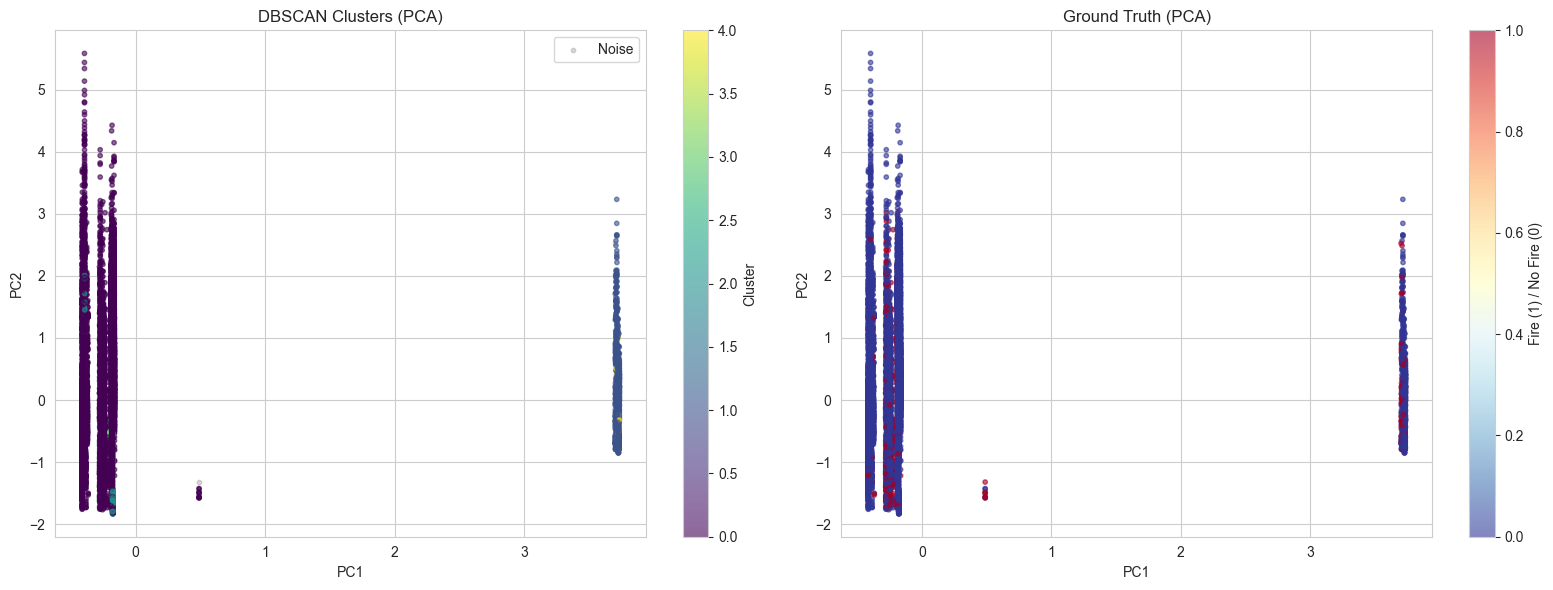

In [59]:
# PCA colored by clusters vs ground truth
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(X_pca[mask_noise, 0], X_pca[mask_noise, 1], c='gray', s=10, alpha=0.3, label='Noise') if np.any(mask_noise) else None
if np.any(mask_clustered):
    sc1 = axes[0].scatter(X_pca[mask_clustered, 0], X_pca[mask_clustered, 1], c=labels[mask_clustered], cmap='viridis', s=10, alpha=0.6)
    plt.colorbar(sc1, ax=axes[0], label='Cluster')
axes[0].set_title('DBSCAN Clusters (PCA)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()

sc2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap='RdYlBu_r', s=10, alpha=0.6)
plt.colorbar(sc2, ax=axes[1], label='Fire (1) / No Fire (0)')
axes[1].set_title('Ground Truth (PCA)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.savefig('../../../../../Rapport_TP/images/DBscan/dbscan_pca_ground_truth.png', dpi=300, bbox_inches='tight')
plt.show()

## **Bayesian Hyperparameter Search**

In [60]:
# Install required package for Bayesian optimization
import subprocess
import sys

try:
    import skopt
except ImportError:
    print("Installing scikit-optimize...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-optimize"])
    import skopt

from skopt import gp_minimize
from skopt.space import Real, Integer
from skopt.utils import use_named_args

In [61]:
# Define objective function for Bayesian optimization
def objective_function(params):
    """
    Objective function to minimize: negative silhouette score
    Higher silhouette = better clusters, so we negate it for minimization
    """
    eps, min_samples = params
    
    try:
        #use PCA-reduced data for faster computation
        pca = PCA(n_components=8, whiten=True, random_state=42)
        X_train_pca = pca.fit_transform(X_train)
        
        dbscan_opt = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1)
        labels_opt = dbscan_opt.fit_predict(X_train_pca)
        
        # Count clusters and noise
        n_clusters = len(set(labels_opt)) - (1 if -1 in labels_opt else 0)
        n_noise = np.sum(labels_opt == -1)
        noise_ratio = n_noise / len(labels_opt)
        
        # Penalize if too many noise points or too few clusters
        if noise_ratio > 0.8 or n_clusters < 2:
            return 1000  # High penalty
        
        # Calculate silhouette score (only on non-noise points)
        if n_clusters > 0:
            mask = labels_opt != -1
            if np.sum(mask) > 1:
                X_non_noise = X_train_pca[mask]
                labels_non_noise = labels_opt[mask]
                if len(np.unique(labels_non_noise)) > 1:
                    sil_score = silhouette_score(X_non_noise, labels_non_noise)
                    # Return negative silhouette (for minimization)
                    return -sil_score
        
        return 1000  # High penalty if metrics can't be computed
    except Exception as e:
        print(f"Error in objective: {e}")
        return 1000


# Define search space
space = [
    Real(0.3, 3.0, name='eps'),           # eps range
    Integer(15, 40, name='min_samples')    # min_samples range
]

print("="*60)
print("BAYESIAN HYPERPARAMETER OPTIMIZATION")
print("="*60)
print("Searching optimal eps and min_samples...")
print("This may take a few minutes...\n")

# Run Bayesian optimization
result = gp_minimize(
    objective_function,
    space,
    n_calls=30,          # Number of iterations
    n_initial_points=5,  # Initial random points
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Extract best parameters
best_eps = result.x[0]
best_min_samples = int(result.x[1])
best_score = -result.fun  # Negate back to get actual silhouette score

print("\n" + "="*60)
print("BAYESIAN OPTIMIZATION RESULTS")
print("="*60)
print(f"Best eps: {best_eps:.4f}")
print(f"Best min_samples: {best_min_samples}")
print(f"Best Silhouette Score: {best_score:.4f}")

BAYESIAN HYPERPARAMETER OPTIMIZATION
Searching optimal eps and min_samples...
This may take a few minutes...

Iteration No: 1 started. Evaluating function at random point.
Iteration No: 1 ended. Evaluation done at random point.
Time taken: 7.9800
Function value obtained: -0.3312
Current minimum: -0.3312
Iteration No: 2 started. Evaluating function at random point.
Iteration No: 2 ended. Evaluation done at random point.
Time taken: 8.0077
Function value obtained: -0.3336
Current minimum: -0.3336
Iteration No: 3 started. Evaluating function at random point.
Iteration No: 3 ended. Evaluation done at random point.
Time taken: 6.1582
Function value obtained: -0.3672
Current minimum: -0.3672
Iteration No: 4 started. Evaluating function at random point.
Iteration No: 4 ended. Evaluation done at random point.
Time taken: 6.1118
Function value obtained: -0.3685
Current minimum: -0.3685
Iteration No: 5 started. Evaluating function at random point.
Iteration No: 5 ended. Evaluation done at random

In [62]:
# Train DBSCAN with optimized parameters
print("\nTraining DBSCAN with optimized parameters...")
start_time = time.time()

dbscan_opt = DBSCAN(eps=best_eps, min_samples=best_min_samples, n_jobs=-1)
labels_opt = dbscan_opt.fit_predict(X_train_pca)
runtime_opt = time.time() - start_time

# Compute metrics with optimized parameters
metrics_opt = compute_dbscan_metrics(X_train, labels_opt, y_train)

print(f"Runtime: {runtime_opt:.2f}s")
print(f"Clusters: {metrics_opt['n_clusters']}")
print(f"Noise points: {metrics_opt['n_noise']} ({metrics_opt['noise_ratio']:.2%})")
print(f"Silhouette Score: {metrics_opt['silhouette'] if metrics_opt['silhouette'] is not None else 'N/A'}")
print(f"Davies-Bouldin Index: {metrics_opt['davies_bouldin'] if metrics_opt['davies_bouldin'] is not None else 'N/A'}")
print(f"Calinski-Harabasz Index: {metrics_opt['calinski_harabasz'] if metrics_opt['calinski_harabasz'] is not None else 'N/A'}")
print(f"AMI: {metrics_opt.get('ami', 'N/A')}")
print(f"ARI: {metrics_opt.get('ari', 'N/A')}")


Training DBSCAN with optimized parameters...
Runtime: 0.71s
Clusters: 11
Noise points: 1495 (9.21%)
Silhouette Score: -0.22684690801758484
Davies-Bouldin Index: 2.3343571668555616
Calinski-Harabasz Index: 199812.16425774415
AMI: 0.04143125122032405
ARI: 0.021979481161104215


In [63]:
# Comparison: Default vs Optimized parameters
print("\n" + "="*60)
print("COMPARISON: DEFAULT vs OPTIMIZED PARAMETERS")
print("="*60)

comparison_data = {
    'Metric': [
        'eps',
        'min_samples',
        'Clusters',
        'Noise Ratio',
        'Silhouette',
        'Davies-Bouldin',
        'Calinski-Harabasz',
        'AMI',
        'ARI'
    ],
    'Default': [
        f"{dbscan.eps:.4f}",
        f"{dbscan.min_samples}",
        f"{metrics['n_clusters']}",
        f"{metrics['noise_ratio']:.2%}",
        f"{metrics['silhouette'] if metrics['silhouette'] is not None else 'N/A'}",
        f"{metrics['davies_bouldin'] if metrics['davies_bouldin'] is not None else 'N/A'}",
        f"{metrics['calinski_harabasz'] if metrics['calinski_harabasz'] is not None else 'N/A'}",
        f"{metrics.get('ami', 'N/A')}",
        f"{metrics.get('ari', 'N/A')}"
    ],
    'Optimized': [
        f"{best_eps:.4f}",
        f"{best_min_samples}",
        f"{metrics_opt['n_clusters']}",
        f"{metrics_opt['noise_ratio']:.2%}",
        f"{metrics_opt['silhouette'] if metrics_opt['silhouette'] is not None else 'N/A'}",
        f"{metrics_opt['davies_bouldin'] if metrics_opt['davies_bouldin'] is not None else 'N/A'}",
        f"{metrics_opt['calinski_harabasz'] if metrics_opt['calinski_harabasz'] is not None else 'N/A'}",
        f"{metrics_opt.get('ami', 'N/A')}",
        f"{metrics_opt.get('ari', 'N/A')}"
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + comparison_df.to_string(index=False))


COMPARISON: DEFAULT vs OPTIMIZED PARAMETERS

           Metric              Default            Optimized
              eps               2.8000               0.8207
      min_samples                   15                   40
         Clusters                    5                   11
      Noise Ratio                0.07%                9.21%
       Silhouette -0.26858461838970066 -0.22684690801758484
   Davies-Bouldin   2.3095050912195423   2.3343571668555616
Calinski-Harabasz   360318.48351000587   199812.16425774415
              AMI  0.01749679787308054  0.04143125122032405
              ARI  0.08719538811235165 0.021979481161104215


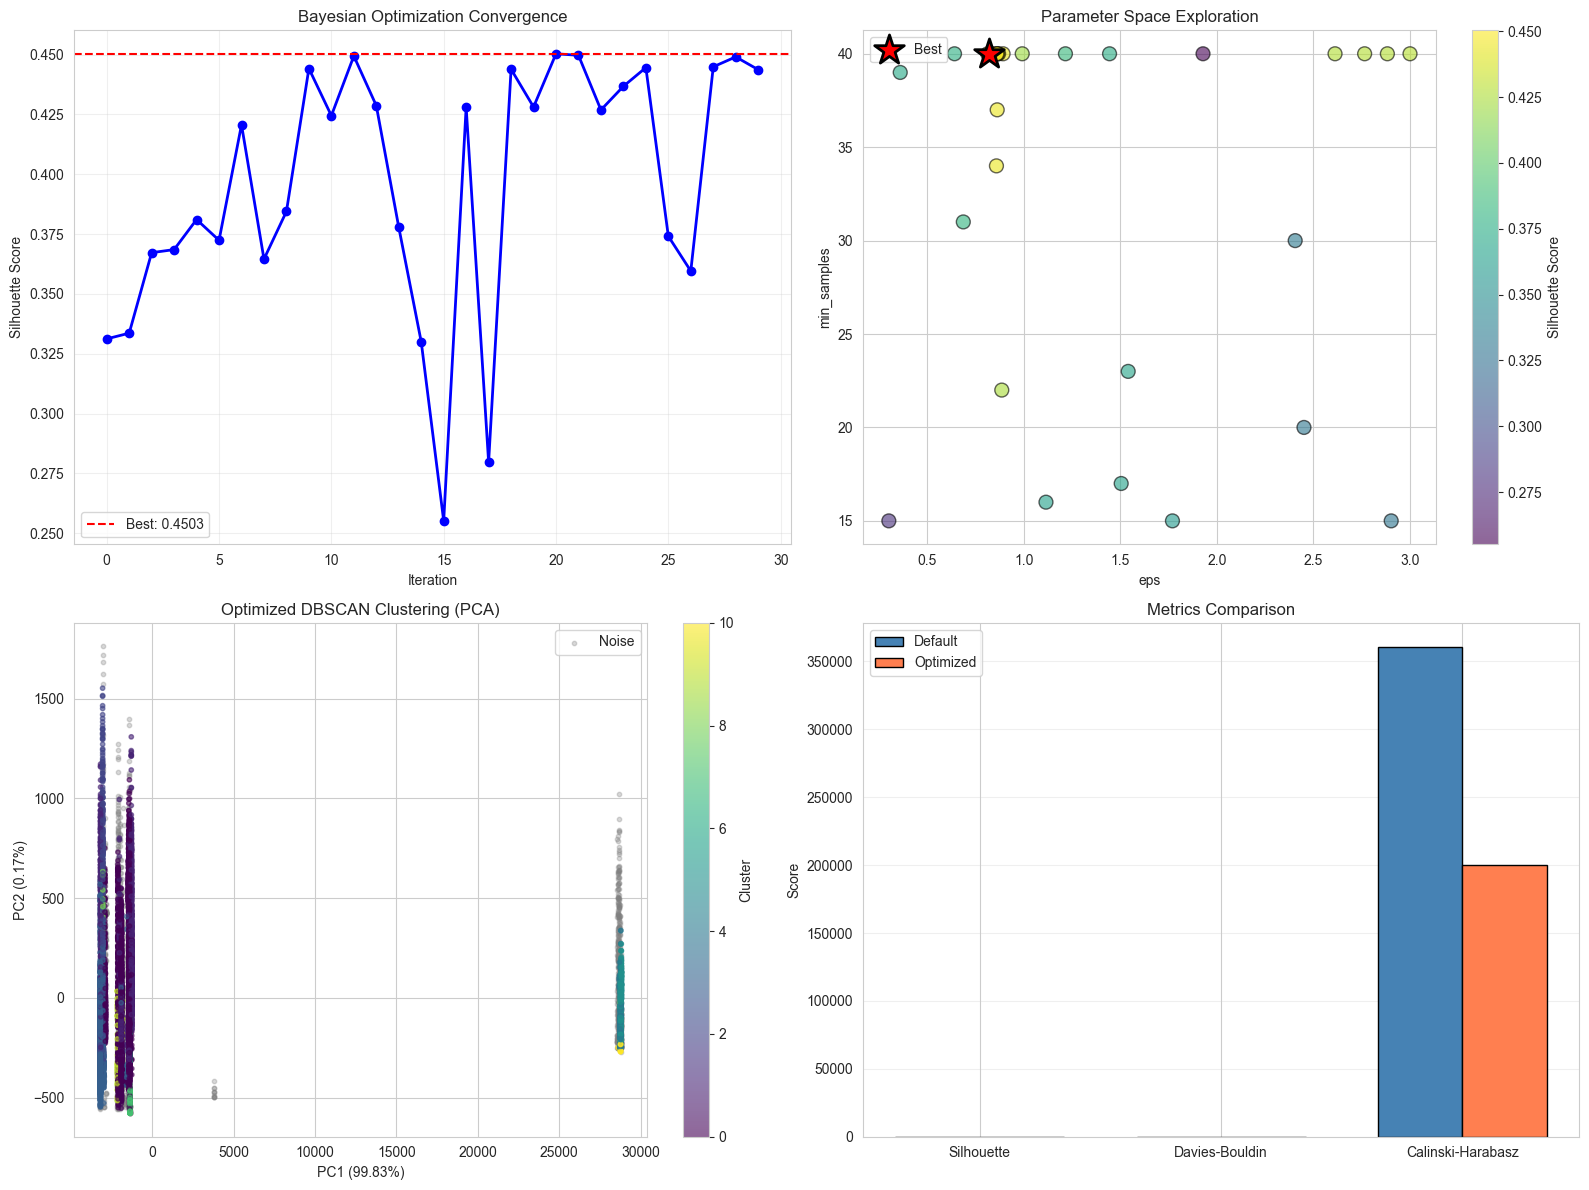


Bayesian optimization visualization complete!


In [64]:
# Visualize optimization history
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Convergence plot
axes[0, 0].plot(range(len(result.func_vals)), -np.array(result.func_vals), 'b-o', linewidth=2, markersize=6)
axes[0, 0].axhline(y=best_score, color='r', linestyle='--', label=f'Best: {best_score:.4f}')
axes[0, 0].set_xlabel('Iteration')
axes[0, 0].set_ylabel('Silhouette Score')
axes[0, 0].set_title('Bayesian Optimization Convergence')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# 2. Parameter exploration scatter plot
eps_vals = [result.x_iters[i][0] for i in range(len(result.x_iters))]
min_samp_vals = [result.x_iters[i][1] for i in range(len(result.x_iters))]
sil_vals = -np.array(result.func_vals)

scatter = axes[0, 1].scatter(eps_vals, min_samp_vals, c=sil_vals, cmap='viridis', s=100, alpha=0.6, edgecolors='black')
axes[0, 1].scatter(best_eps, best_min_samples, c='red', marker='*', s=500, edgecolors='black', linewidths=2, label='Best', zorder=5)
axes[0, 1].set_xlabel('eps')
axes[0, 1].set_ylabel('min_samples')
axes[0, 1].set_title('Parameter Space Exploration')
plt.colorbar(scatter, ax=axes[0, 1], label='Silhouette Score')
axes[0, 1].legend()

# 3. PCA visualization with optimized clusters
pca_vis = PCA(n_components=2)
X_pca_vis = pca_vis.fit_transform(X_train)
mask_noise_opt = labels_opt == -1
mask_clustered_opt = labels_opt != -1

if np.any(mask_noise_opt):
    axes[1, 0].scatter(X_pca_vis[mask_noise_opt, 0], X_pca_vis[mask_noise_opt, 1], c='gray', s=10, alpha=0.3, label='Noise')
if np.any(mask_clustered_opt):
    sc = axes[1, 0].scatter(X_pca_vis[mask_clustered_opt, 0], X_pca_vis[mask_clustered_opt, 1], c=labels_opt[mask_clustered_opt], cmap='viridis', s=10, alpha=0.6)
    plt.colorbar(sc, ax=axes[1, 0], label='Cluster')
axes[1, 0].set_xlabel(f'PC1 ({pca_vis.explained_variance_ratio_[0]:.2%})')
axes[1, 0].set_ylabel(f'PC2 ({pca_vis.explained_variance_ratio_[1]:.2%})')
axes[1, 0].set_title('Optimized DBSCAN Clustering (PCA)')
axes[1, 0].legend()

# 4. Metrics comparison bar plot
metrics_names = ['Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz']
default_vals = [
    metrics['silhouette'] if metrics['silhouette'] is not None else 0,
    metrics['davies_bouldin'] if metrics['davies_bouldin'] is not None else 0,
    metrics['calinski_harabasz'] if metrics['calinski_harabasz'] is not None else 0
]
optimized_vals = [
    metrics_opt['silhouette'] if metrics_opt['silhouette'] is not None else 0,
    metrics_opt['davies_bouldin'] if metrics_opt['davies_bouldin'] is not None else 0,
    metrics_opt['calinski_harabasz'] if metrics_opt['calinski_harabasz'] is not None else 0
]

x = np.arange(len(metrics_names))
width = 0.35

axes[1, 1].bar(x - width/2, default_vals, width, label='Default', color='steelblue', edgecolor='black')
axes[1, 1].bar(x + width/2, optimized_vals, width, label='Optimized', color='coral', edgecolor='black')
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_title('Metrics Comparison')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(metrics_names)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../../../../../Rapport_TP/images/DBscan/dbscan_bayesian_optimization.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nBayesian optimization visualization complete!")